In [1]:
%matplotlib inline

from multiprocessing import Pool
import os
os.environ["OMP_NUM_THREADS"] = "1"

import emcee
import corner
import time
import numpy as np
import scipy.optimize as op
import matplotlib.pyplot as pl
from matplotlib.ticker import MaxNLocator
import matplotlib
matplotlib.rcParams['text.usetex'] = True
from scipy.integrate import odeint
import scipy.integrate as integrate
from scipy.integrate import solve_ivp
import scipy.linalg as linalg
from numpy.linalg import inv, det, pinv
import pandas as pd
import scipy.interpolate
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from getdist import plots


#from EmceeAnalysis import *
#global argsortz#array de indices de zsni ordenados
#global origlen

In [2]:
#output_path = r"C:\Users\pedro\Downloads\programa\exportados"
output_path = r"./fig"
os.makedirs(output_path, exist_ok=True)

In [3]:
#os.chdir("/home/dead/Downloads/LCDMtest/data")
#filename = 'C:\\Users\\pedro\\Downloads\\programa\\Hz32Clocks.txt'
filename = './data/Hz32Clocks.txt'
#filename = 'data/Hz32Clocks.txt' #"/home/dead/Downloads/LCDMtest/data/HzTable_MM_BC03.dat"
zHz, Hzi, errHz = np.genfromtxt(filename, comments='#', usecols=(0,1,2), unpack=True)# delimiter=',')

#filename = 'C:\\Users\\pedro\\Downloads\\programa\\data_MM20.dat'
filename = './data/data_MM20.dat'
#filename = 'data/data_MM20.dat'
zmod, imf, slib, sps, spsooo = np.genfromtxt(filename, comments='#', usecols=(0,1,2,3,4), unpack=True)
print(len(zHz))

32


In [4]:
#zBAO, dA_rd, sdArd = np.genfromtxt('C:\\Users\\pedro\\Downloads\\programa\\DA_rd18.txt', unpack=True)
zBAO, dA_rd, sdArd = np.genfromtxt('./data/DA_rd18.txt', unpack=True)
print(len(zBAO))

18


In [5]:
invcovBAO = np.diag(1./sdArd**2)

In [6]:
#Covariancia de H(z)
cov_mat_diag = np.zeros((len(zHz), len(zHz)), dtype='float64') 

for i in range(len(zHz)):
    cov_mat_diag[i,i] = errHz[i]**2#Erros estatísticos

#Erros sistemáticos
imf_intp = np.interp(zHz, zmod, imf)/100
slib_intp = np.interp(zHz, zmod, slib)/100
sps_intp = np.interp(zHz, zmod, sps)/100
spsooo_intp = np.interp(zHz, zmod, spsooo)/100

cov_mat_imf = np.zeros((len(zHz), len(zHz)), dtype='float64')
cov_mat_slib = np.zeros((len(zHz), len(zHz)), dtype='float64')
cov_mat_sps = np.zeros((len(zHz), len(zHz)), dtype='float64')
cov_mat_spsooo = np.zeros((len(zHz), len(zHz)), dtype='float64')

for i in range(len(zHz)):
    for j in range(len(zHz)):
        cov_mat_imf[i,j] = Hzi[i] * imf_intp[i] * Hzi[j] * imf_intp[j]
        cov_mat_slib[i,j] = Hzi[i] * slib_intp[i] * Hzi[j] * slib_intp[j]
        cov_mat_sps[i,j] = Hzi[i] * sps_intp[i] * Hzi[j] * sps_intp[j]
        cov_mat_spsooo[i,j] = Hzi[i] * spsooo_intp[i] * Hzi[j] * spsooo_intp[j]
        
#Sistemático+estatístico:
cov_mat = cov_mat_spsooo+cov_mat_imf+cov_mat_diag
inv_cov_mat = inv(cov_mat)
inv_cov_mat_diag = inv(cov_mat_diag)

(sign, logdet) = np.linalg.slogdet(cov_mat)
determinant = np.exp(logdet)

In [7]:
#default_data_file = 'C:\\Users\\pedro\\Downloads\\programa\\Pantheon+SH0ES.dat'
#default_covmat_file = 'C:\\Users\\pedro\\Downloads\\programa\\Pantheon+SH0ES_STAT+SYS.cov'
default_data_file = './data/Pantheon+SH0ES.dat'
default_covmat_file = './data/Pantheon+SH0ES_STAT+SYS.cov'

c = 299792.458#km/s

In [8]:
def build_data(datafile,SH0ES):
    """
    Run once at the start to load in the data vectors.
    
    Returns x, y where x is the independent variable (redshift in this case)
    and y is the Gaussian-distribured measured variable (magnitude in this case).
    """
    
    global origlen, wwPS, wwPPlus, cepheid_distance, is_calibrator, zHELPS, zHELPPlus
    filename = datafile
    print("Loading data from {}".format(filename))
    data = pd.read_csv(filename,delim_whitespace=True)
    origlen = len(data)
    
    if SH0ES:
        ww = (data['zHD']>0.01) | (np.array(data['IS_CALIBRATOR'],dtype=bool))
        wwPS = ww
        zHELPS = data['zHEL'][ww]
    else:
        ww = (data['zHD']>0.01)
        wwPPlus = ww
        zHELPPlus = data['zHEL'][ww]

    zCMB = data['zHD'][ww] #use the vpec corrected redshift for zCMB 
    
    m_obs = data['m_b_corr'][ww]
    if SH0ES:
        is_calibrator = data['IS_CALIBRATOR'][ww]
        cepheid_distance = data['CEPH_DIST'][ww]

    return zCMB, m_obs

In [9]:
zCMBPS, m_obsPS = build_data(default_data_file,SH0ES=True)

Loading data from ./data/Pantheon+SH0ES.dat


/tmp/ipykernel_24371/2547134556.py:12: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(filename,delim_whitespace=True)


In [10]:
print(zCMBPS)
print(origlen)
print(len(zCMBPS))

0       0.00122
1       0.00122
2       0.00256
3       0.00256
5       0.00317
         ...   
1696    1.61505
1697    1.69706
1698    1.80119
1699    1.91165
1700    2.26137
Name: zHD, Length: 1657, dtype: float64
1701
1657


In [11]:
zCMBPPlus, m_obsPPlus = build_data(default_data_file,SH0ES=False)

Loading data from ./data/Pantheon+SH0ES.dat


/tmp/ipykernel_24371/2547134556.py:12: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(filename,delim_whitespace=True)


In [12]:
print(zCMBPPlus)
print(origlen)
print(len(zCMBPPlus))

111     0.01016
112     0.01017
113     0.01017
114     0.01026
115     0.01026
         ...   
1696    1.61505
1697    1.69706
1698    1.80119
1699    1.91165
1700    2.26137
Name: zHD, Length: 1590, dtype: float64
1701
1590


In [13]:
def build_covariance(covdatafile, SH0ES):
    """Run once at the start to build the covariance matrix for the data"""
    filename = covdatafile
    print("Loading covariance from {}".format(filename))

    # The file format for the covariance has the first line as an integer
    # indicating the number of covariance elements, and the the subsequent
    # lines being the elements.
    # This function reads in the file and the nasty for loops trim down the covariance
    # to match the only rows of data that are used for cosmology
    f = open(filename)
    line = f.readline()
    if SH0ES:
        n = int(len(zCMBPS))
        ww = wwPS
    else:
        n = int(len(zCMBPPlus))
        ww = wwPPlus
    C = np.zeros((n,n))
    ii = -1
    jj = -1
    mine = 999
    maxe = -999
    for i in range(origlen):
        jj = -1
        if ww[i]:
            ii += 1
        for j in range(origlen):
            if ww[j]:
                jj += 1
            val = float(f.readline())
            if ww[i]:
                if ww[j]:
                    C[ii,jj] = val
    f.close()
    
    print('Done')

        # Return the covariance; the parent class knows to invert this
        # later to get the precision matrix that we need for the likelihood.
    return C

In [14]:
covPS = build_covariance(default_covmat_file, SH0ES=True)
invcovPS = linalg.inv(covPS)
print(invcovPS)

Loading covariance from ./data/Pantheon+SH0ES_STAT+SYS.cov
Done
[[ 3.35362085e+01 -5.68048468e+00 -1.11185732e-01 ...  1.58679951e-02
   1.83028673e-02  6.74379026e-02]
 [-5.68048466e+00  3.26180011e+01  6.90150271e-01 ...  5.80881388e-02
   5.86589637e-02  9.10597742e-02]
 [-1.11185764e-01  6.90150228e-01  5.65408173e+01 ...  4.11968386e-02
   6.05906222e-02  1.44885470e-01]
 ...
 [ 1.58679717e-02  5.80881164e-02  4.11968265e-02 ...  2.64779557e+01
  -2.57859571e-01 -5.21010354e-01]
 [ 1.83028526e-02  5.86589500e-02  6.05906144e-02 ... -2.57859572e-01
   1.63284453e+01 -4.67675982e-01]
 [ 6.74378598e-02  9.10597346e-02  1.44885448e-01 ... -5.21010354e-01
  -4.67675982e-01  2.87332384e+01]]


In [15]:
covPPlus = build_covariance(default_covmat_file, SH0ES=False)
invcovPPlus = linalg.inv(covPPlus)
print(invcovPPlus)

Loading covariance from ./data/Pantheon+SH0ES_STAT+SYS.cov
Done
[[ 1.72105166e+01 -1.20816678e-02  1.30964254e-02 ...  1.95611671e-02
   1.31081169e-02 -1.46529715e-04]
 [-1.20816678e-02  1.78264359e+01 -6.92283034e+00 ...  6.74482896e-02
   2.48972556e-02  8.20426798e-02]
 [ 1.30964254e-02 -6.92283034e+00  2.01507757e+01 ... -1.28370654e-02
  -6.14000122e-03 -1.80441835e-02]
 ...
 [ 1.95611671e-02  6.74482896e-02 -1.28370654e-02 ...  2.64689995e+01
  -2.63020689e-01 -5.31486218e-01]
 [ 1.31081169e-02  2.48972556e-02 -6.14000122e-03 ... -2.63020689e-01
   1.63244378e+01 -4.75757465e-01]
 [-1.46529715e-04  8.20426798e-02 -1.80441835e-02 ... -5.31486218e-01
  -4.75757465e-01  2.87158321e+01]]


In [16]:
par0 = [-19.2, 73.03398760350208, 0.3, 0.1]

In [17]:
 def system(Y, z, OmegaM0, Q0):
    E, u = Y
    Q = Q0
    dE_dz = u
    du_dz = (2 / (1 + z)) * u - (1 / E) * u**2 - (Q / (2 * E**2 * (1 + z)**2))
    return [dE_dz, du_dz]

In [18]:
def Ez(z, theta):
    M, H0, OmegaM0, Q0 = theta
    
    # Condições iniciais
    E0 = 1  # Normalização: H(z=0)/H0 = 1
    u0 = 1.5 * OmegaM0  # Aproximação de dE/dz |_{z=0}
    Y0 = [E0, u0]
    
    # Garante que z seja um array unidimensional
    z_array = np.atleast_1d(z)

    z_array = np.append([0.],z_array)
    
    # Resolver a EDO numericamente
    sol = odeint(system, Y0, z_array, args=(OmegaM0, Q0))

    Ez1 = sol[:, 0]

    Ez1 = np.delete(Ez1,0)
    
    return Ez1  # Retorna apenas E(z)

In [19]:
print(Ez([1.2,1.5],par0))

[1.95515704 2.29615111]


In [20]:
print(Ez(zHz,par0))

[1.03308771 1.04312438 1.0586639  1.08584874 1.09096826 1.10252046
 1.10292542 1.14497513 1.15123123 1.19801172 1.21727808 1.23103939
 1.23131976 1.24852772 1.26316515 1.28151561 1.28768635 1.28895503
 1.37678135 1.44891936 1.51014233 1.53808831 1.62524911 1.62960997
 1.64868104 1.78402163 2.06522897 2.1364569  2.21374911 2.33197004
 2.60349523 2.88307005]


In [21]:
def Ez_1(z,theta):
    return 1./Ez(z,theta)

def odesys(y, z, pars):#y,x,pars
    #Dc, Ez = y
    #alfa, beta, n, wb = pars
    #pars = [wm, wl, H0]
    dydz = Ez_1(z,pars)
    return dydz

def solsys(y0, z, pars):
    #wm, wl, H0 = pars
    return integrate.odeint(odesys, y0, z, args=(pars,), atol=1e-6)

#Distancia comovel de linha-de-visada adimensional (=dc/dH)
def Dcmodel(z,pars):
    #H0, wm, wl = theta
    y0 = 0.
    z = np.append([0.],z)
    sol = solsys(y0, z, pars)[:,0]
    sol = np.delete(sol,0)#sol = np.delete(sol,0.)
    return sol

#Distancia comovel transversal in pc
def dmmodel(z,theta):
    M, H0, wm, Q0 = theta
    dH = c/H0
    wk = 0# - wr
    Dcm = Dcmodel(z,theta)
    #Dcm = np.delete(Dcm,0.)
    if wk < 0:
        return dH*np.sin(np.sqrt(-wk)*Dcm)/np.sqrt(-wk)
    elif wk > 0:
        return dH*np.sinh(np.sqrt(wk)*Dcm)/np.sqrt(wk)
    return dH*Dcm

#distancia de luminosidade in pc
def dlmodel(z,theta):
#    print(z)
    return (1+z)*dmmodel(z,theta)

def dAmodel(z,theta):
#    print(z)
    return dmmodel(z,theta)/(1+z)

def mumodel(z,pars):
#    print(z)
    return 5.*np.log10(dlmodel(z,pars))+25

In [22]:
#Theory points for Pantheon+ and Pantheon+&SH0ES
def extract_theory_points(theory_x, theory_y, pars, SH0ES):
    """
    Run once per parameter set to extract the mean vector that our
    data points are compared to.  For the Hubble flow set, we compare to the 
    cosmological model. For the calibrators we compare to the Cepheid distances.
    """
    M = pars[0]

    # Pull out theory mu and z from the block.
    #theory_x = block[self.x_section, self.x_name]
    #theory_y = block[self.y_section, self.y_name]

    # Interpolation function of theory so we can evaluate at redshifts of the data
    f = scipy.interpolate.interp1d(theory_x, theory_y)#, kind=self.kind)
    
    if SH0ES:
        theory_ynew = zCMBPS*np.nan
        #Here we use the Cepheid host distances as the "theory". 
        #This is the 2nd rung of the distance ladder and is what calibrates M
        theory_ynew[np.array(is_calibrator,dtype='bool')] = cepheid_distance[np.array(is_calibrator,dtype='bool')]
        
        # Actually do the interpolation at the data redshifts
        zcmb = zCMBPS[~np.array(is_calibrator,dtype='bool')]
        zhel = zHELPS[~np.array(is_calibrator,dtype='bool')]
    else:
        theory_ynew = zCMBPPlus*np.nan
        # Actually do the interpolation at the data redshifts
        zcmb = zCMBPPlus
        zhel = zHELPPlus
    
    fz = f(zcmb)
    if np.any(fz<=0):
        NegDist = True
        return 1
    if SH0ES:
        theory_ynew[~np.array(is_calibrator,dtype='bool')] = 5.0*np.log10((1.0+zcmb)*(1.0+zhel)*\
                                                                          np.atleast_1d(fz))+25.
    else:
        theory_ynew = 5.0*np.log10((1.0+zcmb)*(1.0+zhel)*np.atleast_1d(fz))+25.
                
    # Add the absolute supernova magnitude and return
    #M = block[names.supernova_params, "M"]
    return theory_ynew + M

In [23]:
def extract_theory_pointsHz(theory_x, theory_y, pars):
    theory_ynew = zHz*np.nan  # = np.zeros_like(zHz)

    f = scipy.interpolate.interp1d(theory_x, theory_y)#, kind=self.kind)
    theory_ynew = np.atleast_1d(f(zHz))
    return theory_ynew

In [24]:
#zCMB, m_obs = build_dataPS(default_data_file)

In [25]:
#Points for theory interpolation
N = 3000
zt = np.linspace(0,2.5,N)#Vetor de z com 3k componentes pra obter dA(z)

In [26]:
#print(Dcmodel(zBAO,par0))

In [27]:
#BAO from Staicova & Benisty - arXiv: 2107.14129
def chi2BAO(theta):
    vobs = dA_rd
    f = Dcmodel(zBAO,theta)/(1+zBAO)
    A = np.dot(np.dot(f.T,invcovBAO),f)
    B = .5*(np.dot(np.dot(f.T,invcovBAO),vobs)+np.dot(np.dot(vobs.T,invcovBAO),f))
    C = np.dot(np.dot(vobs.T,invcovBAO),vobs)
    return C - B**2/A + np.log(A/(2*np.pi)) #Pode descomentar

def chi2PS(theta):#Pantheon+&SH0ES
    #M = theta[0]
    zsni = zCMBPS
    #Ez2i = Ez(zsni,theta)
    #if np.any(Ez2i <= 0):
        #return np.inf

    dAt = dAmodel(zt,theta)
    NegDist = False
    mmod = extract_theory_points(zt, dAt, theta, SH0ES=True) #5.*np.log10((1+zsni)*(1+zheli)*dAmodi/10)#(dlmodi/10)
    if NegDist:
        return np.inf
    dm = mmod-m_obsPS#mui - (vec1-iscal)*mumod - iscal*mucep - M
    return np.dot(np.dot(dm.T,invcovPS),dm)
    #return np.sum((dmu/smui)**2)
    
def chi2PPlus(theta):#, x, y, invcov):#Pantheon+ only
    #H0, wm, w = theta
    zsni = zCMBPPlus
    #Ez2i = Ez(zsni,theta)
    #if np.any(Ez2i <= 0):
        #return np.inf

    dAt = dAmodel(zt,theta)
    NegDist = False
    mmod = extract_theory_points(zt, dAt, theta,SH0ES=False) #5.*np.log10((1+zsni)*(1+zheli)*dAmodi/10)#(dlmodi/10)
    if NegDist:
        return np.inf
    dmu = mmod-m_obsPPlus
    SA  = np.sum(invcovPPlus)
    Sr  = np.sum(np.dot(dmu.T,invcovPPlus))#np.sum(dmu*invcov)
    Srr = np.dot(np.dot(dmu.T,invcovPPlus),dmu)#np.sum(dmu*dmu*invcov)
    return Srr - Sr**2./SA

def chi2Hz(theta):
    M, H0, wm, Q0 = theta
    Ezt = Ez(zt, theta)
    Hzt = H0 * Ezt
    Hzm = extract_theory_pointsHz(zt, Hzt, theta)
    dh = Hzm - Hzi

    return np.dot(np.dot(dh.T, inv_cov_mat), dh)

def lnprior(theta):
    M, H0, wm, Q0 = theta
    if -19.50 < M < -19 and 40. < H0 < 100. and 0 < wm < 1 and -10 < Q0 < 10:
        return 0.0 
    return -np.inf

def lnlikeHz(par):
    chi2 = chi2Hz(par)
    return -0.5*chi2

def lnprobHz(par):
    lp = lnprior(par)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlikeHz(par)

#lnlike = -chi2/2
def lnlikePS(par):
    chi2 = chi2PS(par)
    return -0.5*chi2
 
def lnprobPS(par):
    lp = lnprior(par)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlikePS(par)

def lnlikePPlus(par):
    chi2 = chi2PPlus(par)
    return -0.5*chi2
 
def lnprobPPlus(par):
    lp = lnprior(par)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlikePPlus(par)

def lnlikeHzPPlus(theta):
    #H0, a1, a2 = theta
    return -.5*(chi2PPlus(theta)+chi2Hz(theta))
# + np.sum(np.log(sigma2)))
 
def lnprobHzPPlus(theta):
    lp = lnprior(theta)
    if not np.isfinite(lp):
        return -np.inf

    like = lnlikeHzPPlus(theta)
    if not np.isfinite(like):  # Se for NaN ou infinito, rejeita a amostra
        return -np.inf

    return lp + like
       
def lnlikeHzPS(theta):
    #H0, a1, a2 = theta
    return -.5*(chi2PS(theta)+chi2Hz(theta))
# + np.sum(np.log(sigma2)))
 
def lnprobHzPS(theta):
    lp = lnprior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlikeHzPS(theta)

def lnlikeHzBAO(theta):
    #H0, a1, a2 = theta
    return -.5*(chi2Hz(theta)+chi2BAO(theta))
# + np.sum(np.log(sigma2)))
 
def lnprobHzBAO(theta):
    lp = lnprior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlikeHzBAO(theta)

def lnlikeHPPB(theta):#, zhzi, hzi, shzi, zsni, mui, invcov):
    #H0, a1, a2 = theta
    return -.5*(chi2PPlus(theta)+chi2Hz(theta)+chi2BAO(theta))
# + np.sum(np.log(sigma2)))
 
def lnprobHPPB(theta):
    lp = lnprior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlikeHPPB(theta)#, zhzi, hzi, shzi, zsni, mui, invcov)

def lnlike(theta):#, zhzi, hzi, shzi, zsni, mui, invcov):
    #H0, a1, a2 = theta
    return -.5*(chi2PS(theta)+chi2Hz(theta)+chi2BAO(theta))
# + np.sum(np.log(sigma2)))
 
def lnprob(theta):
    lp = lnprior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlike(theta)#, zhzi, hzi, shzi, zsni, mui, invcov)

In [28]:
#print(lnprobsn(par0))
print(chi2PS(par0))
print(chi2PPlus(par0))
print(chi2Hz(par0))
#print(chi2BAO(par0))

1807.1375396348353
1407.0182759801567
15.895425662439273


In [29]:
def find_bestfit(lnlike,par_ml):#,data):
   
    t1 = time.time()
    ndim = len(par_ml)
    chi2 = lambda *args: -2 * lnlike(*args)
    result = op.minimize(chi2, par_ml)#, args=data)
    if not result['success']:
        result = op.minimize(chi2, par_ml,method='Nelder-Mead',options={'maxiter': 10000})#, args=data
    par_ml = result["x"]
    print('Maximum likelihood result:')
    for i in range(ndim):
        print(parnames[i],' = ',par_ml[i])
    print('chi2min =',result['fun'])
    #ndof = len(data[0])-ndim
    #print('chi2red =',result['fun']/ndof)
    #print(result)
    t2 = time.time()
    print("tempo total: {0:5.3f} seg".format(t2-t1))
    return result



def plot_chains(sampler,par_ml,parlabtex):
    ndim = len(par_ml)
    pl.clf()
    fig, axes = pl.subplots(ndim, 1, sharex=True, figsize=(8, 9))
    for i in range(ndim):
        axes[i].plot(sampler.chain[:, :, i].T, color="k", alpha=0.4)
        axes[i].yaxis.set_major_locator(MaxNLocator(5))
        axes[i].axhline(par_ml[i], color="#888888", lw=2)
        axes[i].set_ylabel(parlabtex[i])
        
    axes[ndim-1].set_xlabel("step number")
    
    fig.tight_layout(h_pad=0.0)
    pl.show()
#fig.savefig(prefix+"-time.png")

def tira_burnin(sampler,burnin,ndim):
    samples = sampler.chain[:, burnin:, :].reshape((-1, ndim))
    return samples

def burninthin(sampler,tau):
    taumax = np.amax(tau)
    taumin = np.amin(tau)
    samples = sampler.get_chain(discard=int(2*taumax), thin=int(taumin/2), flat=True)
    print(samples.shape)
    return samples

# Make the triangle plot.
def plot_cornertriangle(samples,parlabtex,par_ml):
    #fig = corner.corner(samples,bins=np.sqrt(len(samples)),labels=parlabtex,truths=par_ml)
    fig = corner.corner(samples,bins=50,labels=parlabtex,truths=par_ml)
    pl.show()
#fig.savefig(prefix+"Corner.png")

# Make the triangle plot.
#def plot_cornertriangle(samples,nstep,burnin,parlabtex,par_ml):
#    fig = corner.corner(samples,bins=np.sqrt(nstep-burnin),labels=parlabtex,truths=par_ml)
#fig.savefig(prefix+"Corner.png")

def MC_result(samples,par_ml):
    ndim = len(par_ml)
    par_mean = np.mean(samples,axis=0)
    par_median = np.percentile(samples, [50], axis=0)[0]
    par_valm = np.percentile(samples, [15.865], axis=0)[0]
    par_valp = np.percentile(samples, [84.135], axis=0)[0]
    par_sigm = par_mean - par_valm
    par_sigp = par_valp - par_mean
    print('MCMC result:')
    for i in range(ndim):
        print("""{0} = {1:5.5f} +{2:5.5f} -{3:5.5f} (median: {4:5.5f}, ml: {5:5.5f})"""\
              .format(parnames[i],par_mean[i],par_sigp[i],par_sigm[i],par_median[i],par_ml[i]))

In [30]:
parlabels = ["M", "H_0", r'\Omega_m', r'$\mathcal{Q}_0$']
parlabtex = ["$M$", "$H_0$", r'$\Omega_m$', r'$\mathcal{Q}_0$',]
parnames = ['M', 'H0', 'wm', 'Q0']
#par0F=par0
par_ml        = par0
par_mlHzPS    = par0
par_mlHPPB    = par0
par_mlHzPPlus = par0
ndim = len(par_ml)
prefix = 'Q0Panth+ShBAO18Hz32'

In [31]:
print(par0)
print(ndim)

[-19.2, 73.03398760350208, 0.3, 0.1]
4


In [32]:
resultHzBAO = find_bestfit(lnprobHzBAO, par0)
par_mlHzBAO = resultHzBAO['x']
print(par_mlHzBAO)
print(par_mlHzBAO,'\n')

/home/fernando/anaconda3/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:590: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0
/home/fernando/anaconda3/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:590: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0
/home/fernando/anaconda3/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:590: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0
/home/fernando/anaconda3/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:590: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0


Maximum likelihood result:
M  =  -19.000000000325947
H0  =  68.95902026744577
wm  =  0.07008848917022986
Q0  =  -3.184403587394004
chi2min = 35.10563181632122
tempo total: 5.570 seg
[-19.          68.95902027   0.07008849  -3.18440359]
[-19.          68.95902027   0.07008849  -3.18440359] 



In [33]:
resultHzPS = find_bestfit(lnprobHzPS, par0)
par_mlHzPS = resultHzPS['x']
print(par_mlHzPS)
print(resultHzPS,'\n')

/home/fernando/anaconda3/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:590: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0
/home/fernando/anaconda3/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:590: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0


Maximum likelihood result:
M  =  -19.255897278567424
H0  =  73.01612262421456
wm  =  0.36908501074942374
Q0  =  0.904122426452705
chi2min = 1468.7877452393197
tempo total: 11.967 seg
[-19.25589728  73.01612262   0.36908501   0.90412243]
       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 1468.7877452393197
             x: [-1.926e+01  7.302e+01  3.691e-01  9.041e-01]
           nit: 238
          nfev: 410
 final_simplex: (array([[-1.926e+01,  7.302e+01,  3.691e-01,  9.041e-01],
                       [-1.926e+01,  7.302e+01,  3.691e-01,  9.041e-01],
                       ...,
                       [-1.926e+01,  7.302e+01,  3.691e-01,  9.042e-01],
                       [-1.926e+01,  7.302e+01,  3.691e-01,  9.042e-01]]), array([ 1.469e+03,  1.469e+03,  1.469e+03,  1.469e+03,
                        1.469e+03])) 



In [34]:
resultAll = find_bestfit(lnprob, par0)
par_mlAll = resultAll['x']
print(resultAll)
print(par_mlAll,'\n')

/home/fernando/anaconda3/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:590: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0
/home/fernando/anaconda3/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:590: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0


Maximum likelihood result:
M  =  -19.259954150161917
H0  =  72.99230946773207
wm  =  0.3366668297133769
Q0  =  0.17713532721418013
chi2min = 1492.8559543986435
tempo total: 13.616 seg
       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 1492.8559543986435
             x: [-1.926e+01  7.299e+01  3.367e-01  1.771e-01]
           nit: 212
          nfev: 372
 final_simplex: (array([[-1.926e+01,  7.299e+01,  3.367e-01,  1.771e-01],
                       [-1.926e+01,  7.299e+01,  3.367e-01,  1.771e-01],
                       ...,
                       [-1.926e+01,  7.299e+01,  3.367e-01,  1.772e-01],
                       [-1.926e+01,  7.299e+01,  3.367e-01,  1.771e-01]]), array([ 1.493e+03,  1.493e+03,  1.493e+03,  1.493e+03,
                        1.493e+03]))
[-19.25995415  72.99230947   0.33666683   0.17713533] 



In [35]:
chi2min = resultAll['fun']
print('chi2min =', chi2min)
nsn = len(zCMBPS)
print('nsn =', nsn)
nHz = len(zHz)
print('nHz =', nHz)
ndata = nsn + nHz
print('ndata =', ndata)
npar = len(par_mlAll)
print('npar =', npar)
ndof = ndata - npar
print('ndof =', ndof)
chi2red = chi2min / ndof
print('chi2red =', chi2red)
BIC = chi2min + npar * np.log(ndata)
print('BIC =', BIC)


chi2min = 1492.8559543986435
nsn = 1657
nHz = 32
ndata = 1689
npar = 4
ndof = 1685
chi2red = 0.8859679254591356
BIC = 1522.5835220658746


In [36]:
nwalkers = 100  
ndim = len(par_mlHzPPlus)  
ainput = 2.0  
nstep = 3000  
pos = [par_mlHzPPlus + 1e-4 * np.random.randn(ndim) for i in range(nwalkers)]

In [37]:
def run_emcee(par_ml, nwalkers, lnprob, ainput, nstep):
    ndim = len(par_ml)
    pos = [par_ml + 1e-4 * np.random.randn(ndim) for i in range(nwalkers)]
    
    sampler = emcee.EnsembleSampler(nwalkers, ndim, lnprob, a=ainput)
    sampler.run_mcmc(pos, nstep, progress=True)

    accept = sampler.acceptance_fraction
    print('Acceptance fraction:', accept)
    print('Minimum acceptance:', np.amin(accept))
    print('Maximum acceptance:', np.amax(accept))

    return sampler

In [38]:
samplerHzBAO = run_emcee(par_mlHzBAO, 100, lnprobHzBAO, 2.0, 3500)

  0%|                                                                                                                                                          | 0/3500 [00:00<?, ?it/s]/home/fernando/anaconda3/lib/python3.12/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3500/3500 [28:46<00:00,  2.03it/s]

Acceptance fraction: [0.54628571 0.50828571 0.516      0.52228571 0.50057143 0.51914286
 0.52057143 0.51742857 0.514      0.54228571 0.51742857 0.50657143
 0.49828571 0.50771429 0.53828571 0.51942857 0.49428571 0.51314286
 0.514      0.49914286 0.51685714 0.51942857 0.51371429 0.47971429
 0.51257143 0.53142857 0.50657143 0.53514286 0.52657143 0.51485714
 0.52257143 0.51371429 0.51628571 0.53114286 0.53685714 0.51857143
 0.53171429 0.49571429 0.52057143 0.54485714 0.496      0.55
 0.50885714 0.51571429 0.50457143 0.516      0.53628571 0.53142857
 0.49657143 0.49828571 0.51771429 0.50857143 0.52714286 0.51428571
 0.50428571 0.50628571 0.54485714 0.50542857 0.52742857 0.50714286
 0.52542857 0.534      0.52885714 0.52257143 0.52742857 0.51828571
 0.53971429 0.502      0.51257143 0.518      0.508      0.52028571
 0.51828571 0.51114286 0.53085714 0.512      0.51457143 0.48685714
 0.51771429 0.54028571 0.5        0.49714286 0.51314286 0.494
 0.51485714 0.52742857 0.50828571 0.51885714 0.50085

In [39]:
tauHzBAO = samplerHzBAO.get_autocorr_time(tol=0)
print(tauHzBAO)
taumaxHzBAO = np.amax(tauHzBAO)
rHzBAO = 3500 / taumaxHzBAO
print(rHzBAO)
if(rHzBAO>50):
    print('Convergiu! :)')
else:
    print('Nao convergiu... :(')

[56.9504134  54.13559091 65.8617622  65.98094736]
53.045616042247104
Convergiu! :)


<Figure size 640x480 with 0 Axes>

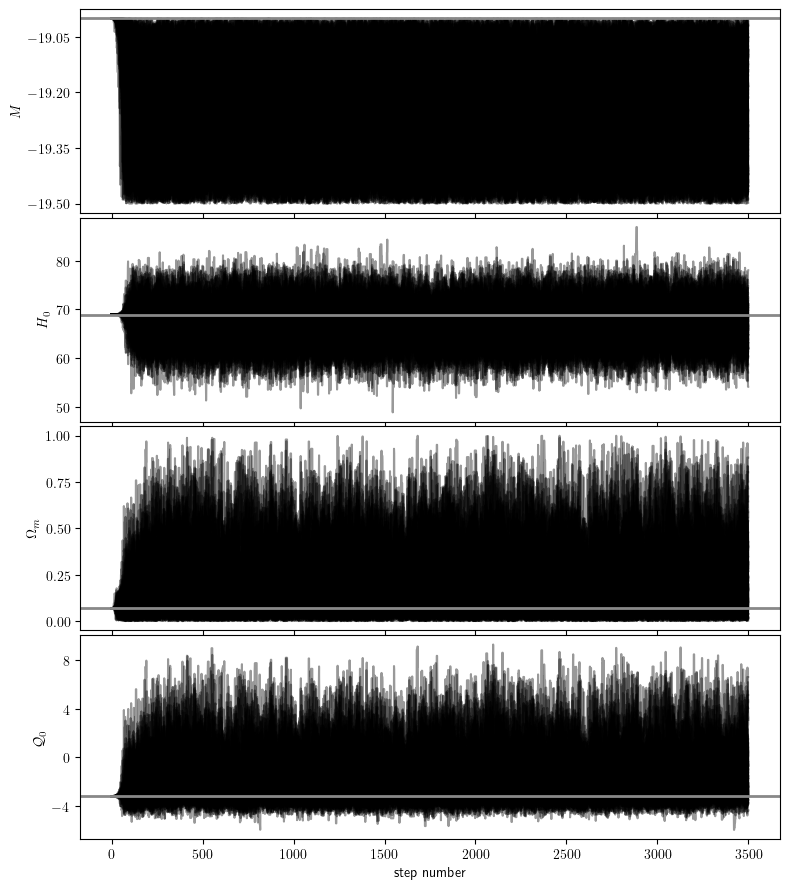

(12400, 4)


In [40]:
plot_chains(samplerHzBAO, par_mlHzBAO, parlabtex)
samplesHzBAO = burninthin(samplerHzBAO, tauHzBAO)

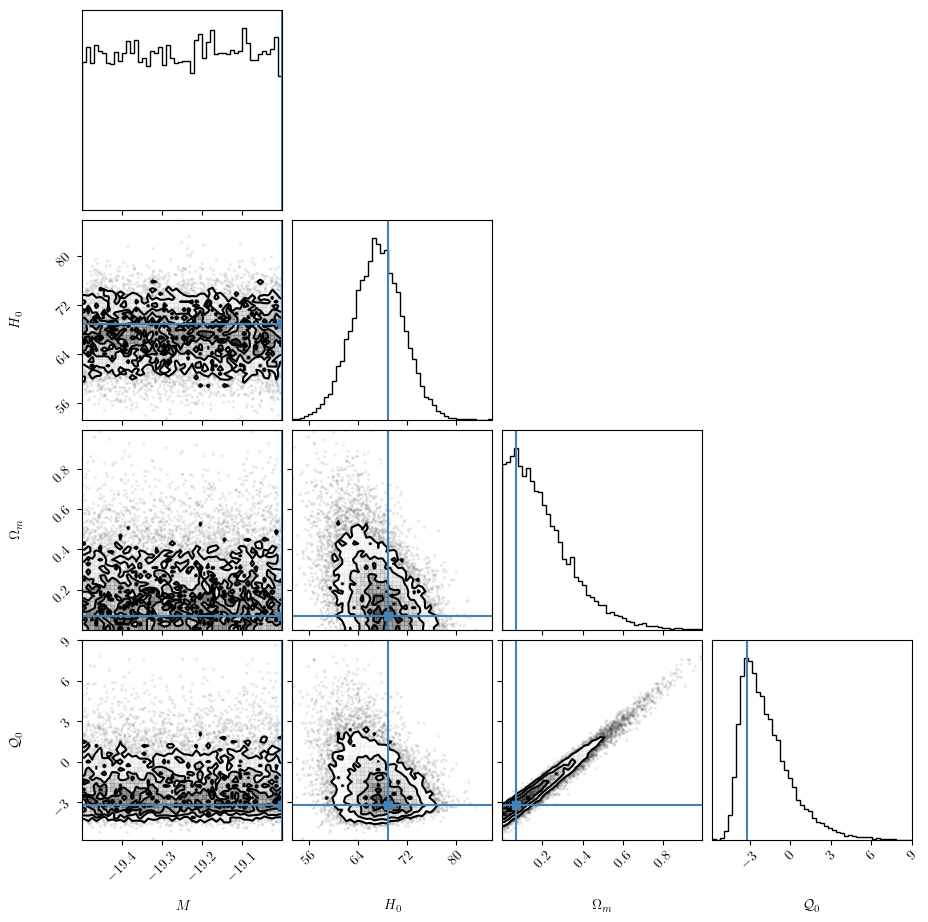

MCMC result:
M = -19.24868 +0.16816 -0.17074 (median: -19.24655, ml: -19.00000)
H0 = 67.28397 +4.04719 -4.08906 (median: 67.32106, ml: 68.95902)
wm = 0.20277 +0.15209 -0.15143 (median: 0.16822, ml: 0.07009)
Q0 = -1.72285 +1.77075 -1.72349 (median: -2.14365, ml: -3.18440)


In [41]:
plot_cornertriangle(samplesHzBAO, parlabtex, par_mlHzBAO)
MC_result(samplesHzBAO, par_mlHzBAO)

In [42]:
samplerHzPS = run_emcee(par_mlHzPS, 100, lnprobHzPS, 2.0, nstep)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3000/3000 [1:37:06<00:00,  1.94s/it]

Acceptance fraction: [0.606      0.58366667 0.59766667 0.588      0.57766667 0.57666667
 0.60033333 0.60533333 0.589      0.608      0.607      0.58166667
 0.608      0.58533333 0.59266667 0.60866667 0.58833333 0.58666667
 0.594      0.58933333 0.59966667 0.59833333 0.59766667 0.60533333
 0.594      0.60766667 0.60766667 0.58733333 0.595      0.596
 0.592      0.60333333 0.59766667 0.601      0.614      0.61133333
 0.594      0.57966667 0.59433333 0.61566667 0.583      0.613
 0.60066667 0.59033333 0.585      0.58133333 0.59633333 0.58533333
 0.601      0.60066667 0.611      0.591      0.58566667 0.58233333
 0.598      0.58933333 0.59933333 0.593      0.601      0.613
 0.593      0.608      0.61166667 0.60333333 0.59566667 0.588
 0.59233333 0.60166667 0.59366667 0.60733333 0.60133333 0.595
 0.59033333 0.59033333 0.58366667 0.59133333 0.609      0.58866667
 0.607      0.59466667 0.59733333 0.595      0.59466667 0.60233333
 0.594      0.59633333 0.584      0.597      0.604      0.59933333

In [43]:
tauHzPS = samplerHzPS.get_autocorr_time(tol=0)
print(tauHzPS)
taumaxHzPS = np.amax(tauHzPS)
rHzPS = nstep / taumaxHzPS
print(rHzPS)
if(rHzPS>50):
    print('Convergiu! :)')
else:
    print('Nao convergiu... :(')

[40.37808081 39.56390467 39.55382524 39.51323253]
74.29773629126174
Convergiu! :)


<Figure size 640x480 with 0 Axes>

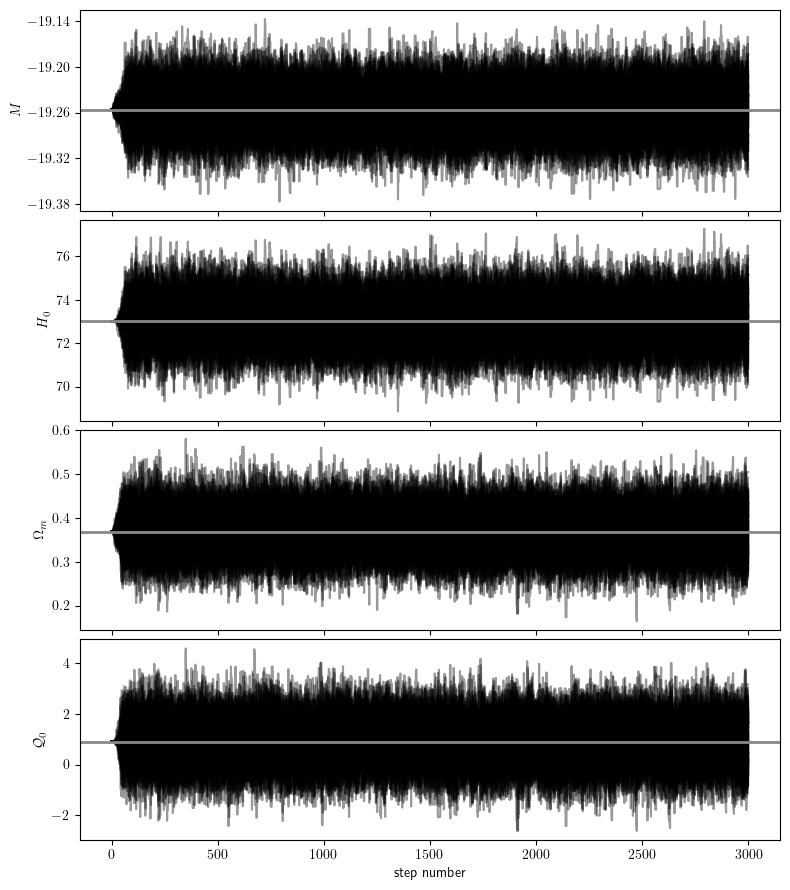

(15300, 4)


In [44]:
plot_chains(samplerHzPS, par_mlHzPS, parlabtex)
samplesHzPS = burninthin(samplerHzPS, tauHzPS)

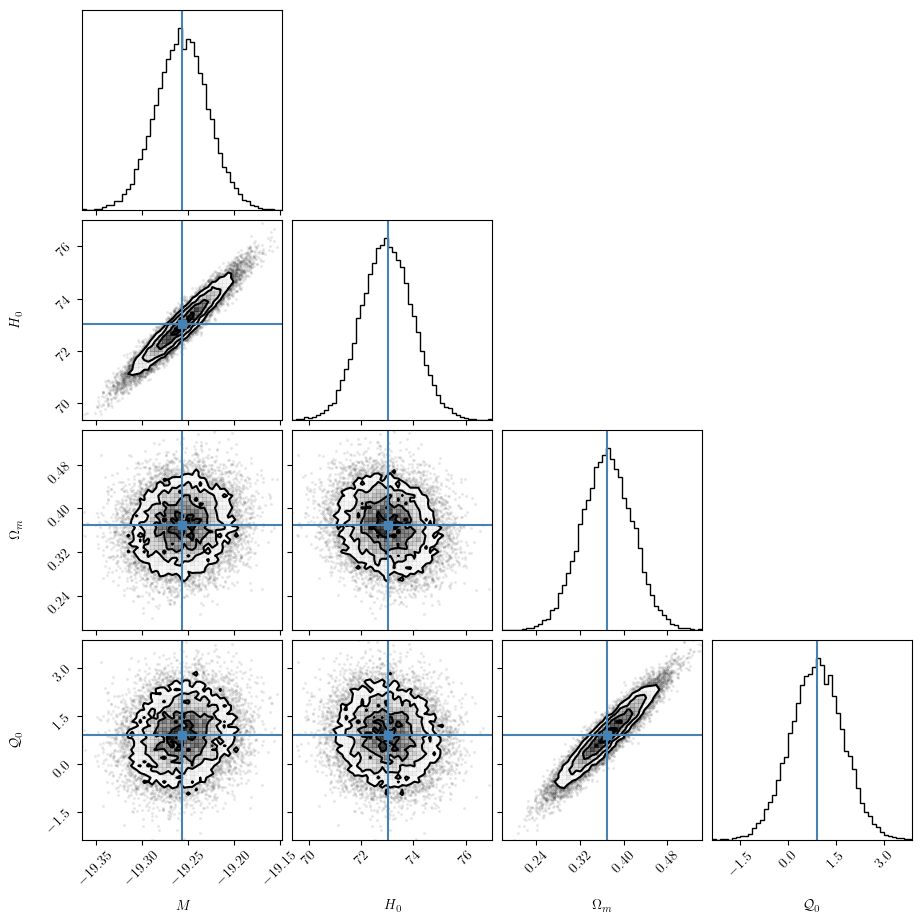

MCMC result:
M = -19.25620 +0.02821 -0.02847 (median: -19.25626, ml: -19.25590)
H0 = 73.00480 +0.98781 -0.98456 (median: 72.99585, ml: 73.01612)
wm = 0.36967 +0.04749 -0.04698 (median: 0.36975, ml: 0.36909)
Q0 = 0.89889 +0.82662 -0.82354 (median: 0.90345, ml: 0.90412)


In [45]:
plot_cornertriangle(samplesHzPS, parlabtex, par_mlHzPS)
MC_result(samplesHzPS, par_mlHzPS)

In [46]:
samplerAll = run_emcee(par_mlAll, 100, lnprob, 2.0, nstep)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3000/3000 [2:21:44<00:00,  2.83s/it]

Acceptance fraction: [0.602      0.593      0.60366667 0.597      0.596      0.582
 0.60466667 0.60866667 0.607      0.60766667 0.60833333 0.59566667
 0.60633333 0.59433333 0.597      0.588      0.59266667 0.588
 0.60666667 0.58033333 0.62033333 0.59166667 0.59333333 0.599
 0.60566667 0.60733333 0.58466667 0.58566667 0.59533333 0.591
 0.58466667 0.60366667 0.58466667 0.59633333 0.60333333 0.60566667
 0.604      0.586      0.595      0.60033333 0.584      0.611
 0.60133333 0.58633333 0.59566667 0.575      0.608      0.59266667
 0.60866667 0.60766667 0.59733333 0.602      0.589      0.593
 0.59366667 0.60066667 0.61566667 0.586      0.60166667 0.60733333
 0.59366667 0.60166667 0.607      0.61633333 0.604      0.59366667
 0.613      0.58533333 0.59733333 0.60933333 0.596      0.59733333
 0.596      0.59166667 0.605      0.595      0.607      0.58833333
 0.58066667 0.586      0.58566667 0.59666667 0.59166667 0.58166667
 0.61033333 0.596      0.584      0.585      0.59366667 0.59033333
 0.5

In [47]:
tauAll = samplerAll.get_autocorr_time(tol=0)
print(tauAll)
taumaxAll = np.amax(tauAll)
rAll = nstep / taumaxAll
print(rAll)
if(rAll>50):
    print('Convergiu! :)')
else:
    print('Nao convergiu... :(')

[41.77744343 42.67750063 43.00816757 41.39599808]
69.75419250457831
Convergiu! :)


<Figure size 640x480 with 0 Axes>

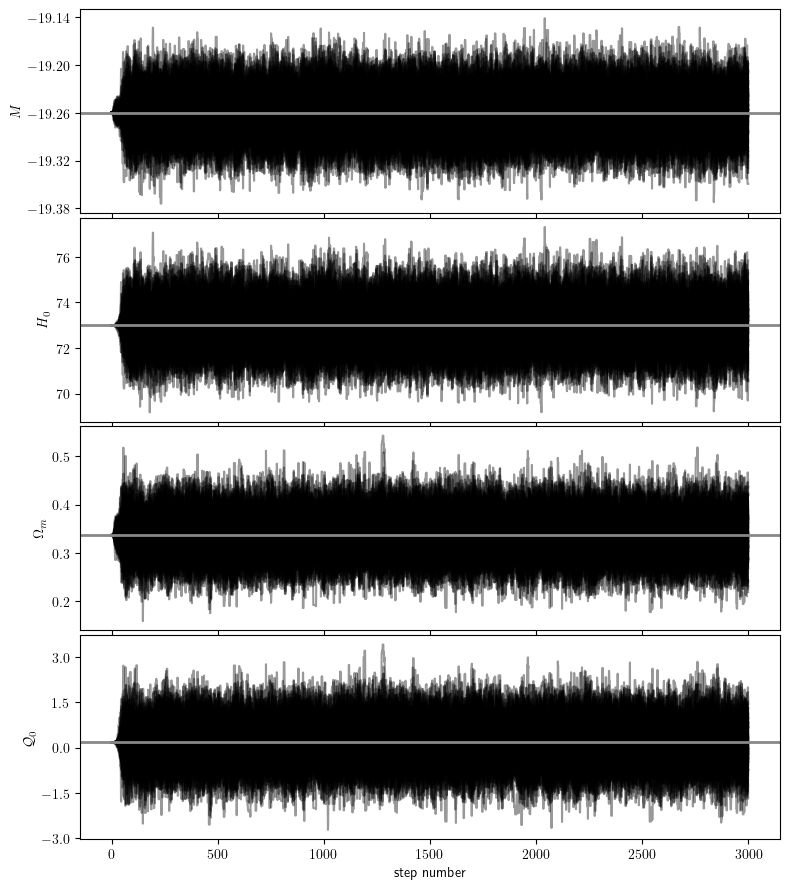

(14500, 4)


In [48]:
plot_chains(samplerAll, par_mlAll, parlabtex)
samplesAll = burninthin(samplerAll, tauAll)

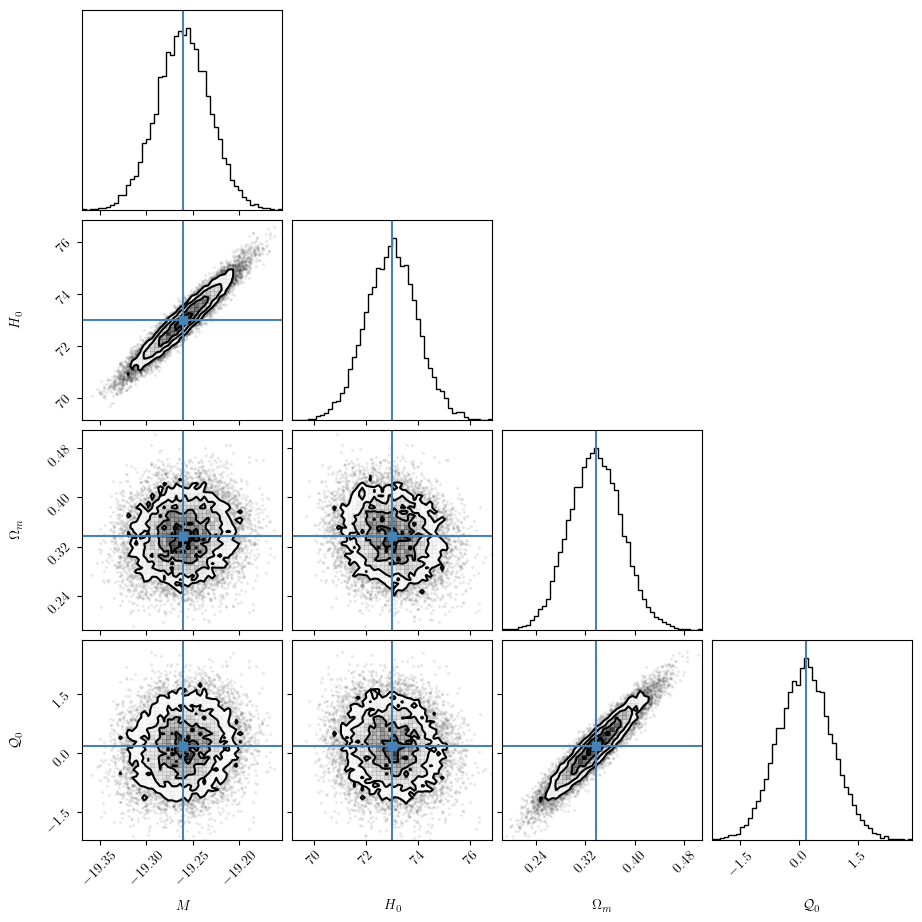

MCMC result:
M = -19.26004 +0.02842 -0.02829 (median: -19.25997, ml: -19.25995)
H0 = 72.99394 +0.97394 -0.99044 (median: 72.99970, ml: 72.99231)
wm = 0.33660 +0.04226 -0.04317 (median: 0.33636, ml: 0.33667)
Q0 = 0.16224 +0.69274 -0.70672 (median: 0.16705, ml: 0.17714)


In [49]:
plot_cornertriangle(samplesAll, parlabtex, par_mlAll)
MC_result(samplesAll, par_mlAll)

In [50]:
from getdist import plots, MCSamples
import getdist, IPython
print('Version: ',getdist.__version__)

Version:  1.5.4


In [51]:
gsamplesHzBAO = MCSamples(samples=samplesHzBAO, names=parnames, labels=parlabels)
gsamplesHzBAO.updateSettings({'contours': [0.682689492137, 0.954499736104, 0.997300203937]})

gsamplesHzPS = MCSamples(samples=samplesHzPS, names=parnames, labels=parlabels)
gsamplesHzPS.updateSettings({'contours': [0.682689492137, 0.954499736104, 0.997300203937]})

gsamplesAll = MCSamples(samples=samplesAll, names=parnames, labels=parlabels)
gsamplesAll.updateSettings({'contours': [0.682689492137, 0.954499736104, 0.997300203937]})

Removed no burn in
Removed no burn in
Removed no burn in


In [52]:
g = plots.getSubplotPlotter(width_inch=6)
g.triangle_plot([gsamplesAll], filled=True, legend_labels=[r'CC+BAO+Pantheon+\&SH0ES'])
g.export(os.path.join(output_path, "Q0_combinados_6.pdf"))

In [53]:
g = plots.getSubplotPlotter(width_inch=6)
g.triangle_plot([gsamplesHzBAO, gsamplesHzPS, gsamplesAll], filled=True,
                legend_labels=["CC+BAO", r"CC+Pantheon+\&SH0ES", r"CC+BAO+Pantheon+\&SH0ES"])
g.export(os.path.join(output_path, "Q0_separados_6.pdf"))

In [54]:
print("\nTabela - CC+BAO")
for i in range(len(par0)):
    for j in range(1, 4):
        print(gsamplesHzBAO.getInlineLatex(parnames[i], limit=j))
print(gsamplesHzBAO.getTable().tableTex())


Tabela - CC+BAO
M = -19.25\pm 0.14
M = -19.25^{+0.24}_{-0.24}
M = -19.25^{+0.25}_{-0.25}
H_0 = 67.3\pm 4.1
H_0 = 67^{+8}_{-8}
H_0 = 67^{+10}_{-10}
\Omega_m = 0.203^{+0.052}_{-0.20}
\Omega_m = 0.20^{+0.34}_{-0.21}
\Omega_m = 0.20^{+0.67}_{-0.22}
$\mathcal{Q}_0$ = -1.72^{+0.87}_{-2.2}
$\mathcal{Q}_0$ = -1.7^{+4.1}_{-2.8}
$\mathcal{Q}_0$ = -1.7^{+8.4}_{-3.1}
\begin{tabular} { l  c}

 Parameter &  95\% limits\\
\hline
{\boldmath$M              $} & $-19.25^{+0.24}_{-0.24}    $\\

{\boldmath$H_0            $} & $67^{+8}_{-8}              $\\

{\boldmath$\Omega_m       $} & $0.20^{+0.34}_{-0.21}      $\\

{\boldmath$\mathcal{Q}_0$} & $-1.7^{+4.1}_{-2.8}        $\\
\hline
\end{tabular}


In [55]:
print("\nTabela - CC+Pantheon+SH0ES")
for i in range(len(par0)):
    for j in range(1, 4):
        print(gsamplesHzPS.getInlineLatex(parnames[i], limit=j))
print(gsamplesHzPS.getTable().tableTex())



Tabela - CC+Pantheon+SH0ES
M = -19.256\pm 0.028
M = -19.256^{+0.057}_{-0.057}
M = -19.256^{+0.086}_{-0.086}
H_0 = 73.00\pm 0.98
H_0 = 73.0^{+2.0}_{-1.9}
H_0 = 73.0^{+2.9}_{-3.0}
\Omega_m = 0.370\pm 0.047
\Omega_m = 0.370^{+0.094}_{-0.094}
\Omega_m = 0.37^{+0.15}_{-0.14}
$\mathcal{Q}_0$ = 0.90\pm 0.83
$\mathcal{Q}_0$ = 0.9^{+1.7}_{-1.7}
$\mathcal{Q}_0$ = 0.9^{+2.5}_{-2.5}
\begin{tabular} { l  c}

 Parameter &  95\% limits\\
\hline
{\boldmath$M              $} & $-19.256^{+0.057}_{-0.057} $\\

{\boldmath$H_0            $} & $73.0^{+2.0}_{-1.9}        $\\

{\boldmath$\Omega_m       $} & $0.370^{+0.094}_{-0.094}   $\\

{\boldmath$\mathcal{Q}_0$} & $0.9^{+1.7}_{-1.7}         $\\
\hline
\end{tabular}


In [56]:
print("\nTabela - CC+BAO+Pantheon+SH0ES")
for i in range(len(par0)):
    for j in range(1, 4):
        print(gsamplesAll.getInlineLatex(parnames[i], limit=j))
print(gsamplesAll.getTable().tableTex())


Tabela - CC+BAO+Pantheon+SH0ES
M = -19.260\pm 0.029
M = -19.260^{+0.058}_{-0.058}
M = -19.260^{+0.085}_{-0.083}
H_0 = 72.99\pm 0.99
H_0 = 73.0^{+2.0}_{-2.0}
H_0 = 73.0^{+3.0}_{-2.8}
\Omega_m = 0.337\pm 0.043
\Omega_m = 0.337^{+0.087}_{-0.084}
\Omega_m = 0.34^{+0.13}_{-0.12}
$\mathcal{Q}_0$ = 0.16\pm 0.69
$\mathcal{Q}_0$ = 0.2^{+1.4}_{-1.4}
$\mathcal{Q}_0$ = 0.2^{+2.1}_{-2.1}
\begin{tabular} { l  c}

 Parameter &  95\% limits\\
\hline
{\boldmath$M              $} & $-19.260^{+0.058}_{-0.058} $\\

{\boldmath$H_0            $} & $73.0^{+2.0}_{-2.0}        $\\

{\boldmath$\Omega_m       $} & $0.337^{+0.087}_{-0.084}   $\\

{\boldmath$\mathcal{Q}_0$} & $0.2^{+1.4}_{-1.4}         $\\
\hline
\end{tabular}


In [57]:
print(np.shape(samplesAll))
print(parnames)

(14500, 4)
['M', 'H0', 'wm', 'Q0']
